PART 1: NEURAL NETWORK MODEL

In [47]:
from google.colab import files
uploaded = files.upload()



import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

from keras.models import Sequential
from keras.layers import Dense, Dropout, Conv2D, MaxPool2D, Flatten

Saving international-visitors-london.csv to international-visitors-london (3).csv


In [48]:
pip install keras tensorflow

In [49]:
df = pd.read_csv('international-visitors-london.csv', encoding='latin-1')
df.head(10)

,year,quarter,market,dur_stay,mode,purpose,area,Visits (000s),Spend (£m),Nights (000s),sample
0,2002,January-March,Belgium,1-3 nights,Air,Holiday,LONDON,3.572186,0.969138,6.954456,5
1,2002,January-March,Belgium,1-3 nights,Air,Business,LONDON,9.284226,2.399577,12.604959,19
2,2002,January-March,Belgium,1-3 nights,Air,VFR,LONDON,0.877182,0.089833,2.153128,3
3,2002,January-March,Belgium,1-3 nights,Air,Miscellaneous,LONDON,0.163874,0.010160,0.163874,1
4,2002,January-March,Belgium,1-3 nights,Sea,Business,LONDON,1.648670,0.016789,1.650300,1
5,2002,January-March,Belgium,1-3 nights,Sea,Miscellaneous,LONDON,0.590807,0.003953,1.772420,1
6,2002,January-March,Belgium,1-3 nights,Tunnel,Holiday,LONDON,10.940251,2.765473,23.242688,30
7,2002,January-March,Belgium,1-3 nights,Tunnel,Business,LONDON,6.052632,1.446697,10.428555,16
8,2002,January-March,Belgium,1-3 nights,Tunnel,VFR,LONDON,5.559403,0.468140,9.441416,13
9,2002,January-March,Belgium,1-3 nights,Tunnel,Miscellaneous,LONDON,0.704948,0.465721,1.409894,2


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61462 entries, 0 to 61461
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   year           61462 non-null  object 
 1   quarter        61462 non-null  object 
 2   market         61462 non-null  object 
 3   dur_stay       61462 non-null  object 
 4   mode           61462 non-null  object 
 5   purpose        61462 non-null  object 
 6   area           61462 non-null  object 
 7   Visits (000s)  61462 non-null  float64
 8   Spend (£m)     61462 non-null  float64
 9   Nights (000s)  61462 non-null  float64
 10  sample         61462 non-null  int64  
dtypes: float64(3), int64(1), object(7)
memory usage: 5.2+ MB


In [51]:
df.describe()

,Visits (000s),Spend (£m),Nights (000s),sample
count,61462.000000,61462.000000,61462.000000,61462.000000
mean,4.927651,3.086634,30.300852,6.099021
std,10.061362,7.243874,61.898302,13.335820
min,0.000103,0.000000,0.000309,1.000000
25%,0.822888,0.321693,3.901581,1.000000
50%,1.797305,1.047351,10.676935,2.000000
75%,4.416618,3.007542,29.483044,5.000000
max,187.487282,373.232590,2492.178513,299.000000


In [52]:
print(df.isnull().sum())


year             0
quarter          0
market           0
dur_stay         0
mode             0
purpose          0
area             0
Visits (000s)    0
Spend (£m)       0
Nights (000s)    0
sample           0
dtype: int64


In [53]:
print(df.columns.tolist())

['year', 'quarter', 'market', 'dur_stay', 'mode', 'purpose', 'area', 'Visits (000s)', 'Spend (£m)', 'Nights (000s)', 'sample']


I define my target "y" and everything else goes to X.
The data set contain categorical columns, I need to convert it int 0 and 1
to be able to read it with Neural Nerwork, so I used One-Hot enncode for it.  

In [75]:
target = 'Spend (£m)'#set my target £ and store in "y"
y = df[target].values

X_raw = df.drop(columns=[target])#Drop my target and everything else belongs to "X"
X_encoded = pd.get_dummies(X_raw)#This only runs on X, itconverts text columns to numbers

training_columns = X_encoded.columns.tolist()

print('Features shape after encoding:', X_encoded.shape)
print('Target shape:', y.shape)

Features shape after encoding: (61462, 101)
Target shape: (61462,)


I applyed Standar scaller to normalize all the values, since all the columns
contains numbers from 1 to 61,000 to ensure every feature contibutes equally.

I keep unseen 20% of the data so the model should be training on the 80%

In [55]:
scaler = StandardScaler()#Normalization. standarize all the range of values in the data set
X = scaler.fit_transform(X_encoded)

#I set the usal 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=17)

#shape 1 represent the columns, testing and training have the same No. of columns
print("Training samples after encoded:", X_train.shape[1])
print("Number of testing rows: ", X_test.shape[0])#shape 0 are the rows
print("Number of training rows:", X_train.shape[0])


Training samples after encoded: 101
Number of testing rows:  12293
Number of training rows: 49169


Sequesntial model will build one layer after other till we get the output.
Layer 1: look at the raw data
Layer 2 look at layer 1
Layer 3: looks at layer 2 and offer only 1 output

At first I tried 250 neurons, but the time and the resuls didnt work out
I changed it to 64,32,1, this way it improved a lot.
I choosed Relu to handle non linear relationships
I had to try Dropout 0.2 because still the Training and validation MAE werent
the best, It disabled 20% of neurons during the training process, I have
a lot of data, so my model probably was memorizing the data, I did improve a bit.


In [56]:
#stack of layers, add layers one by one
model = Sequential()


#input the 101 columns, activation "relu" to learns complex platterns.
model.add(Dense(64, input_dim=101, activation='relu'))
model.add(Dropout(0.2))
#Hidden layer is activation function, it learn non linear patterns
model.add(Dense(42, activation='relu'))
model.add(Dropout(0.2))
#this layer is the output(1), it has to be linear regression instead of sigmoid
model.add(Dense(1, activation='linear'))

If this is a regression model, then we use Mean Square Error and Mean Absolute Error
Mean Square Error measures the average difference between the predicted value "spend", and the actual "spend"
Mean Absolute Error tells the average absolute difference between predicted and actual "spend"

In [57]:


#input x neurons + biases = Paramseters


model.compile(loss='mse', optimizer='adam', metrics=['mae'])
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 64)             │         6,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 42)             │         2,730 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            43 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,301 (36.33 KB)

 Trainable params: 9,301 (36.33 KB)

 Non-trainable params: 0 (0.00 B)

I choose 200 epoch because I did a test with 100 and 250, and it wasnt a good balance, also the running time was very excesive. I had to increse the batch size from 10 to 32, that is a good balance for my 49K+ rows, but again it was try and test to find out.


In [63]:

history = model.fit(X_train, y_train, epochs=200, batch_size=32,
                    validation_data=(X_test, y_test))

Epoch 1/200
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 8.1536 - mae: 1.3055 - val_loss: 24.7035 - val_mae: 1.3776
Epoch 2/200
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 8.2158 - mae: 1.3066 - val_loss: 24.0189 - val_mae: 1.3230
Epoch 3/200
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 7.6755 - mae: 1.2884 - val_loss: 23.8533 - val_mae: 1.3685
Epoch 4/200
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 7.9516 - mae: 1.3023 - val_loss: 24.7038 - val_mae: 1.2989
Epoch 5/200
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 8.0156 - mae: 1.3047 - val_loss: 24.0925 - val_mae: 1.2685
Epoch 6/200
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 7.7816 - mae: 1.2965 - val_loss: 24.2336 - val_mae: 1.4033
Epoch 7/200
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 8.1978 - mae: 1.2952 - val_loss: 24.2569 - val_mae: 1.4169
Epoch 8/200
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 7.9378 - mae: 1.3017 - val_loss: 24.1253 - val_mae: 1.3561
Epoch 9/200
1537/1537 ━━

In [64]:
acc = history.history['mae']
val_acc = history.history['val_mae']

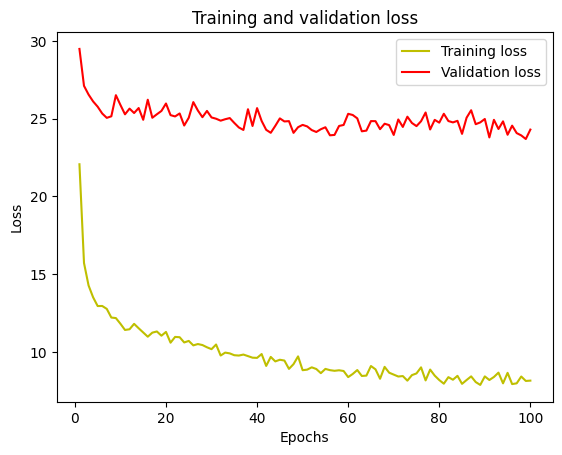

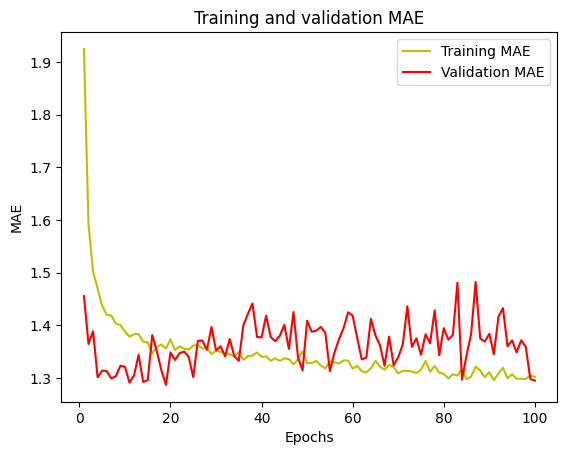

In [62]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)

plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

mae = history.history['mae']
val_mae = history.history['val_mae']

plt.plot(epochs, mae, 'y', label='Training MAE')
plt.plot(epochs, val_mae, 'r', label='Validation MAE')
plt.title('Training and validation MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.show()

In the evaluation the Mean Absolute Error is 1.31, I mean 1.31 away from the actual Spend.
The Mean Squared Error is high, is overpredicting every time.

Looking at the 5 samples, 5 out of 5 are aoverpredicting. the model may have very low or very very high values, that are being squared in the MSE, and it can be causing the overprediction.

The final R2 por Neural Network model is 58.03 %
Lets see if a Random Forest model can do a better job

In [66]:
scores = model.evaluate(X_test, y_test, verbose=0)
print("Neural Network Evaluation")
print("MSE : %.4f" % scores[0])
print("MAE : %.4f" % scores[1])

Neural Network Evaluation
MSE : 25.5742
MAE : 1.3173


In [70]:
predictions = model.predict(X_test)
print("Sample Predictions vs Actual")
for i in range(5):
    print("Predicted: £%.2fm  =>  Actual: £%.2fm" % (predictions[i][0], y_test[i]))

385/385 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Sample Predictions vs Actual
Predicted: £0.58m  =>  Actual: £0.08m
Predicted: £0.80m  =>  Actual: £0.36m
Predicted: £1.67m  =>  Actual: £1.14m
Predicted: £2.00m  =>  Actual: £1.24m
Predicted: £1.12m  =>  Actual: £0.49m


In [72]:
mae_nn  = mean_absolute_error(y_test, predictions)
rmse_nn = np.sqrt(mean_squared_error(y_test, predictions))
r2_nn   = r2_score(y_test, predictions)

print("Neural Network")
print("MAE  : %.4f" % mae_nn)
print("RMSE : %.4f" % rmse_nn)
print("R²   : %.4f" % r2_nn)

Neural Network
MAE  : 1.3173
RMSE : 5.0571
R²   : 0.5803


Random Forest:
In general NN perform better in 2 out of 3 metrics, Random Forest is competitive but not excatly better than NN.

If we look at R2: NN wins
If we look at RMSE: NN wins again and
If we look at MAE: Random Forest wins, but this is a very small difference to be
considered as impactfull.

I would considare Nerural Network a better model to predict "spend".
To achieve this, to modify the neurons and Dropout was key, since it was clearly overfitting excessively. In that way then NN can explains 58% of the "spends", by looking at features like "travel purposes", "nights of stay" etc. The other 42% is likely driven by factors that do not belong to this data set.  



In [73]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_predictions = rf.predict(X_test)

mae_rf  = mean_absolute_error(y_test, rf_predictions)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_predictions))
r2_rf   = r2_score(y_test, rf_predictions)

print("Random Forest")
print("MAE  : %.4f" % mae_rf)
print("RMSE : %.4f" % rmse_rf)
print("R²   : %.4f" % r2_rf)

=== Random Forest ===
MAE  : 1.2536
RMSE : 5.3157
R²   : 0.5363


In [74]:
results = pd.DataFrame({
    'Model' : ['Neural Network', 'Random Forest'],
    'MAE'   : [mae_nn,  mae_rf],
    'RMSE'  : [rmse_nn, rmse_rf],
    'R²'    : [r2_nn,   r2_rf]
})
print(results.round(4).to_string(index=False))

         Model    MAE   RMSE     R²
Neural Network 1.3173 5.0571 0.5803
 Random Forest 1.2536 5.3157 0.5363


Visitors prediction:


This is a new group of people, I defined its characteristics with 5200 visitors, and 12,500 nights etc. Since this data do not belongs to the initial
data set I have to apply again One-hot encode, scale it and add them to the
101 columns I got before.

The results predicted a French group that potentially would spend 4.88 millions in London.

In [77]:
new_visitor = pd.DataFrame({
    'year':           [2024],
    'quarter':        ['April-June'],
    'market':         ['France'],
    'dur_stay':       ['4-7 nights'],
    'mode':           ['Air'],
    'purpose':        ['Holiday'],
    'area':           [' LONDON'],
    'Visits (000s)':  [5.2],
    'Nights (000s)':  [12.5],
    'sample':         [15]
})


new_encoded = pd.get_dummies(new_visitor)
new_encoded = new_encoded.reindex(columns=training_columns, fill_value=0)
new_scaled = scaler.transform(new_encoded)


In [78]:
predicted_spend = model.predict(new_scaled)
print("New Visitor Profile")
print("Market: France - Mode: Air - Purpose: Holiday")
print("Duration: 4-7 nights - Quarter: April-June")
print("Visits: 5,200 - Nights: 12,500")
print("Predicted Spend: £%.2fm" % predicted_spend[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
New Visitor Profile
Market: France - Mode: Air - Purpose: Holiday
Duration: 4-7 nights - Quarter: April-June
Visits: 5,200 - Nights: 12,500
Predicted Spend: £4.88m


PART 2: SEMANTIC ANALYSIS

Analysis of "shopee reviews", label raitings and analysis.
Before labeling we had 8,680 5 stars reviews, after labeling we ended up with 9,406, which basically can be all the 5 and 4 stars unified.
I used the 3 labels requestes Positive, Neutral and Negative using lambda functions.
I used textblob, it contain its own dicctionary and helped me to decide which revew seems to ba positive or not.

Texblob decresed the poitive raiting from 9,405 to 8,475, and in Neutral and Negative raitings, increased almost the double.
This demostrate the importance of analysis of words, any business owner would rely on the first 9,405 good raintings, but in reallity are 8,475, not a big difference but it can impact when the desicions making are made.






This data set contains 137.65MB, it contains way too many values but it is the only one I found without the labels.  
Data set from: https://www.kaggle.com/datasets/shymammoth/shopee-reviews




In [89]:
from google.colab import files
uploaded = files.upload()

Saving shopee_reviews.csv to shopee_reviews.csv


In [100]:
import seaborn as sns

In [90]:
#I'll reduce the rows
df_reviews = pd.read_csv('shopee_reviews.csv', nrows=10000)
df_reviews.head(10)

,label,text
0,5,Looks ok. Not like so durable. Will hv to use ...
1,5,"Tried, the current can be very powerful depend..."
2,5,Item received after a week. Looks smaller than...
3,5,Thanks!!! Works as describe no complaints. Not...
4,5,Fast delivery considering it’s from overseas a...
5,5,Fast delivery good service
6,5,Got my order and it came well packaged. Have y...
7,5,Items received in a nice box. Have not used it...
8,5,"Received in good condition, tried so far so go..."
9,1,Item doesn’t work . \n\nAsked me to send a ref...


In [91]:
df_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   10000 non-null  int64 
 1   text    9999 non-null   object
dtypes: int64(1), object(1)
memory usage: 156.4+ KB


In [92]:
df_reviews.describe()

,label
count,10000.000000
mean,4.764600
std,0.712066
min,1.000000
25%,5.000000
50%,5.000000
75%,5.000000
max,5.000000


In [93]:
print(df_reviews.isnull().sum())#the data set in pretty much clean

label    0
text     1
dtype: int64


In [94]:
#We have mainly 5 raiting stars
print(df_reviews['label'].value_counts())


label
5    8680
4     726
3     315
1     161
2     118
Name: count, dtype: int64


In [95]:
#I would love to visualize some of the text, i use Index Location to give a number to the rows
print(df_reviews['text'].iloc[0])
print(df_reviews['text'].iloc[1])
print(df_reviews['text'].iloc[2])

Looks ok. Not like so durable. Will hv to use a while to recommend others of its worth.
Tried, the current can be very powerful depending on the setting, i don't dare to go higher but if go higher sure muscle will become sore and can see the effect faster.
Item received after a week. Looks smaller than expected, can’t wait to try!


In [102]:
#Define what is positive, negative adn neutral

df_reviews['Polarity_Rating'] = df_reviews['label'].apply(
    lambda x: 'Positive' if x > 3 else ('Neutral' if x == 3 else 'Negative'))

print(df_reviews['Polarity_Rating'].value_counts())
df_reviews.head()

Polarity_Rating
Positive    9406
Neutral      315
Negative     279
Name: count, dtype: int64


,label,text,Polarity_Rating
0,5,Looks ok. Not like so durable. Will hv to use ...,Positive
1,5,"Tried, the current can be very powerful depend...",Positive
2,5,Item received after a week. Looks smaller than...,Positive
3,5,Thanks!!! Works as describe no complaints. Not...,Positive
4,5,Fast delivery considering it’s from overseas a...,Positive


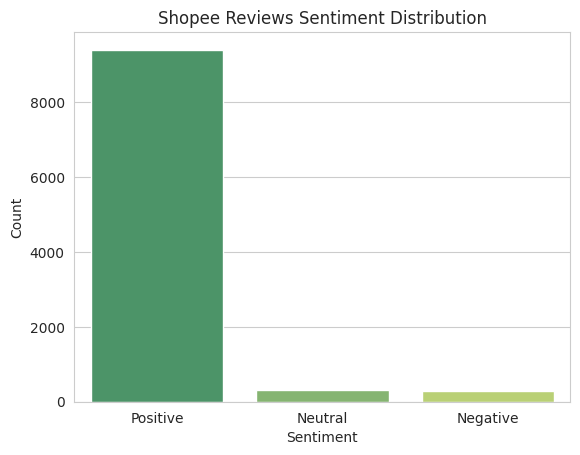

In [105]:
sns.set_style('whitegrid')
sns.countplot(x='Polarity_Rating', data=df_reviews,
              palette='summer',
              order=['Positive', 'Neutral', 'Negative'])
plt.title('Shopee Reviews Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

In [106]:
from textblob import TextBlob
df_reviews.dropna(inplace=True)

#Texblob to analyse the text, here we can actuall see 5 starts review with a score of -06, textblob
#recognised negative words there
df_reviews['sentiment_score'] = df_reviews['text'].apply(
    lambda x: TextBlob(str(x)).sentiment[0])

df_reviews.head()

,label,text,Polarity_Rating,sentiment_score
0,5,Looks ok. Not like so durable. Will hv to use ...,Positive,0.400000
1,5,"Tried, the current can be very powerful depend...",Positive,0.278000
2,5,Item received after a week. Looks smaller than...,Positive,-0.062500
3,5,Thanks!!! Works as describe no complaints. Not...,Positive,0.180208
4,5,Fast delivery considering it’s from overseas a...,Positive,-0.016667


In [107]:
df_reviews['sentiment_textblob'] = df_reviews['sentiment_score'].apply(
    lambda x: 'Positive' if x > 0 else ('Neutral' if x == 0 else 'Negative'))

print(df_reviews['sentiment_textblob'].value_counts())

sentiment_textblob
Positive    8475
Neutral      796
Negative     728
Name: count, dtype: int64


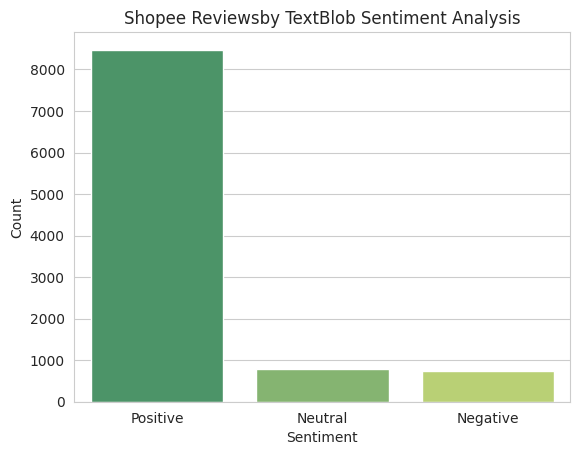

In [109]:
sns.set_style('whitegrid')
sns.countplot(x='sentiment_textblob', data=df_reviews,
              palette='summer',
              order=['Positive', 'Neutral', 'Negative'])
plt.title('Shopee Reviewsby TextBlob Sentiment Analysis')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()


In [111]:
#omparison table
rating_counts = df_reviews['Polarity_Rating'].value_counts()
textblob_counts = df_reviews['sentiment_textblob'].value_counts()


comparison = pd.DataFrame({
    'Initial Rating': rating_counts,
    'TextBlob': textblob_counts
})

print("Sentiment Comparison")
print(comparison)

Sentiment Comparison
          Initial Rating  TextBlob
Positive            9405      8475
Neutral              315       796
Negative             279       728


## References

Chollet, F. (2015) Keras. Available at: https://keras.io (Accessed: 31 May 2026).

Pedregosa, F. et al. (2011) 'Scikit-learn: Machine Learning in Python',
Journal of Machine Learning Research, 12, pp. 2825-2830.
Available at: https://scikit-learn.org (Accessed: 31 May 2026).

Loria, S. (2018) TextBlob Documentation. Available at:
https://textblob.readthedocs.io (Accessed: 31 May 2026).

TensorFlow Developers (2023) TensorFlow. Available at:
https://www.tensorflow.org (Accessed: 31 May 2026).

Visit Britain (2023) International Visitors London Dataset.
Available at: Moodle, CCT College Dublin (Accessed: April 2026).

Kaggle (2023) Shopee Product Reviews Dataset. Available at:
https://www.kaggle.com (Accessed: 31 May 2026).

McQuaid, D. (2026) Machine Learning for AI — Course Materials.
CCT College Dublin [Unpublished lecture notes].

DigitalSreeni (2021) 141 - Regression using Neural Networks and
comparison to other models [Online video]. YouTube.
Available at: https://www.youtube.com/watch?v=2yhLEx2FKoY
(Accessed: 31 May 2026).